In [19]:
import numpy as np
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.

In [21]:
img = cv2.imread("mountain.jpg")

In [23]:
base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.get_layer('block3_conv3').output)

In [25]:
img = cv2.resize(img, (224, 224))

In [27]:
print(img.min(),img.max())

0 255


In [29]:
img = img / 255.0

In [31]:
print(img.min(),img.max())

0.0 1.0


In [33]:
img.shape

(224, 224, 3)

In [35]:
img = np.expand_dims(img, axis=0)  # 1 additional dimension is added for no. of images i.e 1 in our use case

In [37]:
img.shape

(1, 224, 224, 3)

In [39]:
features = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [40]:
features.shape

(1, 56, 56, 256)

In [41]:
features = features.reshape(-1,features.shape[-1])

In [42]:
features.shape

(3136, 256)

In [43]:
features

array([[-0.       , -0.       , -0.       , ..., 14.407687 ,  8.421301 ,
        -0.       ],
       [-0.       , -0.       , -0.       , ...,  5.1328287,  4.8654995,
        -0.       ],
       [-0.       , -0.       , -0.       , ...,  3.077709 ,  2.6492321,
        -0.       ],
       ...,
       [15.836126 , 16.170399 , -0.       , ..., 10.099912 , -0.       ,
        -0.       ],
       [15.821473 , 25.656328 , -0.       , ...,  8.768229 , -0.       ,
        -0.       ],
       [ 9.989837 , 30.372465 , -0.       , ..., -0.       , -0.       ,
         3.5096405]], dtype=float32)

In [49]:
from sklearn.decomposition import PCA

In [51]:
pca = PCA(n_components=3)
rgb = pca.fit_transform(features)

In [52]:
print(rgb.min(),rgb.max())

-72.14785 171.46904


In [55]:
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

In [57]:
print(rgb.min(),rgb.max())

0.0 1.0


In [59]:
rgb = (rgb * 255).astype(np.uint8)

In [61]:
print(rgb.min(),rgb.max())

0 255


In [63]:
rgb.shape

(3136, 3)

In [65]:
base_model.trainable = False

In [67]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,488 (6.62 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,735,488 (6.62 MB)

C:\Users\ARSHIYA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\ARSHIYA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


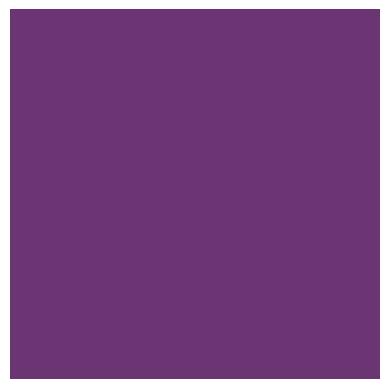

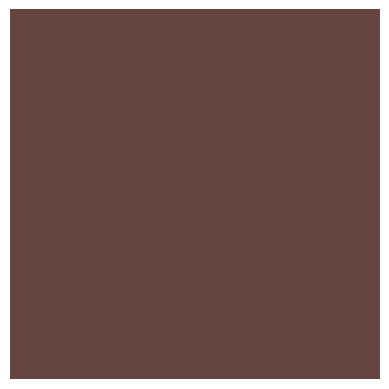

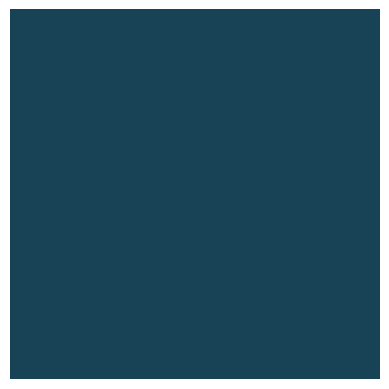

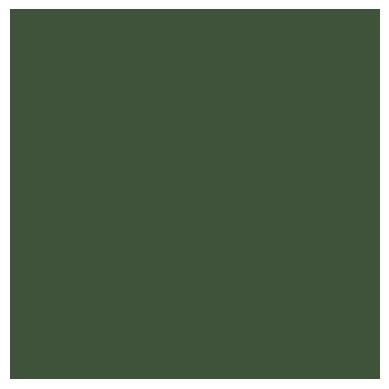

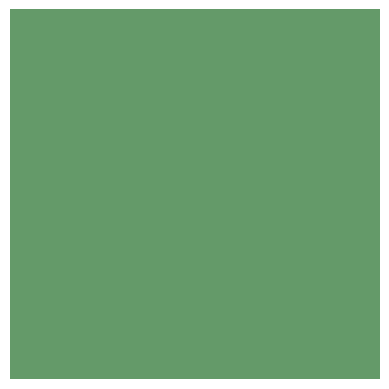

In [69]:
model = KMeans(n_clusters=5,init='k-means++')
model.fit(rgb)
centroids = model.cluster_centers_
colors = np.array(centroids, dtype='uint8')

cnt = 0
for color in colors:
        plt.axis('off')
        mat = np.zeros((3, 3, 3), dtype='uint8')
        mat[:, :, :] = color

        plt.imshow(mat)
        plt.show()